In [2]:
import os
import json
from pathlib import Path

import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

MODEL_DIR = Path(r"C:/CV_PROJECT/ITMO/designing_neural_network_architectures_2025_02/seminar_05/models/qwen2.5_vlm_2b")

IMAGE_DIR = "./data"
OUTPUT_FILE = "dataset.jsonl"

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f"Каталог модели не найден: {MODEL_DIR}")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    str(MODEL_DIR),
    device_map="auto",
    torch_dtype=torch.float16,
    quantization_config=quantization_config,
    local_files_only=True,
)

processor = AutoProcessor.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
)

print("Модель загружена из:", MODEL_DIR.resolve())


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Модель загружена из: C:\CV_PROJECT\ITMO\designing_neural_network_architectures_2025_02\seminar_05\models\qwen2.5_vlm_2b


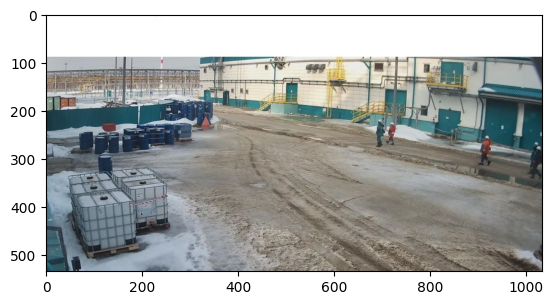

Промпт: Сколько людей в кадре? Опиши их очень подробно
Ответ: На изображении видно несколько людей, которые идут по улице. Они носят рабочую одежду, включая куртки, брюки и защитные очки. Улица покрыта снегом, что создает негативную атмосферу. Вдали от них видны строения, которые могут быть частью предприятия или склада.


In [15]:
import matplotlib.pyplot as plt
import cv2

TEST_IMAGE = Path("3.JPG")  # путь к картинке

image = cv2.imread(TEST_IMAGE)[:,:,::-1]
plt.imshow(image)
plt.show()

TEST_PROMPT = "Сколько людей в кадре? Опиши их очень подробно"

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(TEST_IMAGE)},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)

In [17]:
files = sorted(os.listdir(IMAGE_DIR))

len(files)

174

In [19]:

PROMPT = """
Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files[:5]:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": PROMPT
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    item = {
        "image": image_path,
        "text": output_text
    }

    all_items.append(item)

    print(output_text)


Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
В изображении представлено просторное помещение, возможно, это офис или учебный класс. На переднем плане видны несколько стеллажей, на которых хранятся различные предметы, включая коробки. В центре изображения находится стол, на котором лежит несколько папок. В левом углу можно увидеть человека, который занимается чем-то на полке.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
На изображении представлено просторное помещение, возможно, это лаборатория или офис. В центре находится длинный стол, на котором лежит несколько коробок. Вокруг стола и на поле видны различные предметы, включая мебель, например, на заднем плане видны мебельные шкафы. Вокруг стола есть люди, которые занимаются чем-то, неизвестно, что они делают.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
На изображении представлено помещение, в котором видны несколько людей, сидящих за столами, а так

In [18]:


with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Saved to {OUTPUT_FILE}")

Saved to dataset.jsonl
